# Step 7: Zero-shot aesthetic tags

This notebook compares the board's vibe vector against a fixed list of style words (cottagecore, minimalist, streetwear, etc.) to get broad "vibe tags" for the board -- with no training of our own involved.

## What "zero-shot" means here

Every step so far compared an image embedding to *another image* embedding (board vs. items). This step is different: we compare the board's image embedding to *text* embeddings instead.

This works because of how CLIP was trained: on millions of (image, caption) pairs, learning to pull an image's embedding and its matching caption's embedding close together in the same 512-dimensional space, and push unrelated pairs apart. The practical result is that images and text share one coordinate system -- a picture of a cottagecore outfit and the *word* "cottagecore" end up pointing in a similar direction in that space, even though the model was never specifically trained to classify "cottagecore vs. minimalist vs. streetwear."

That's what "zero-shot" means: we're not training a classifier on our own labeled examples for these categories (that's Step 8, later, using the dataset's real `usage` labels). We're just asking a model that already understands these concepts, for free, by embedding the label words themselves and measuring which ones land closest to our vibe vector.

## Load the vibe vector and FashionCLIP

Self-contained, same as previous notebooks.

In [1]:
from pathlib import Path
import numpy as np
import torch
from transformers import CLIPModel, CLIPProcessor

vibe_vector = np.load(Path("../data/embeddings/board_vibe_vector.npy"))

MODEL_NAME = "patrickjohncyh/fashion-clip"
device = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Using device: {device}")

model = CLIPModel.from_pretrained(MODEL_NAME).to(device)
model.eval()
processor = CLIPProcessor.from_pretrained(MODEL_NAME)

print("Model loaded. Vibe vector shape:", vibe_vector.shape)

Using device: mps


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Model loaded. Vibe vector shape: (512,)


## The aesthetic vocabulary, and why we wrap each word in a sentence

Below is a fixed list of broad style/aesthetic labels -- feel free to edit this list later to fit your own boards better.

Notice we don't embed the bare word (`"cottagecore"`) -- we wrap it in a template sentence (`"a photo of an outfit in the cottagecore aesthetic"`). This is a known CLIP technique called **prompt engineering**: CLIP was trained on full image *captions*, not single keywords, so a full sentence tends to land in a more reliable, expected region of the embedding space than an isolated word does. The wording of the template can noticeably shift results -- this is a real, if slightly unsatisfying, part of working with CLIP-style models in practice.

In [2]:
AESTHETIC_LABELS = [
    "cottagecore", "dark academia", "y2k", "minimalist", "streetwear",
    "preppy", "grunge", "bohemian", "athleisure", "old money",
    "coquette", "gorpcore", "clean girl", "coastal grandmother",
    "punk", "romantic", "androgynous", "vintage", "glam",
]

PROMPT_TEMPLATE = "a photo of an outfit in the {} aesthetic"
prompts = [PROMPT_TEMPLATE.format(label) for label in AESTHETIC_LABELS]

prompts[:3]  # peek at the first few

['a photo of an outfit in the cottagecore aesthetic',
 'a photo of an outfit in the dark academia aesthetic',
 'a photo of an outfit in the y2k aesthetic']

## Embed all the label prompts at once

The processor can tokenize a whole list of strings in one call (`padding=True` pads shorter prompts with filler tokens so they all form a single rectangular batch tensor). This is the text-encoder equivalent of what `model.get_image_features` did for images -- and it has the same output-object quirk we ran into in notebook 02, so we again pull the actual embedding out of `.pooler_output`.

We also L2-normalize every prompt embedding here, same as we did for the vibe vector back in notebook 02 -- since both sides are now unit length, cosine similarity simplifies to a plain dot product.

In [3]:
inputs = processor(text=prompts, return_tensors="pt", padding=True).to(device)

with torch.no_grad():
    outputs = model.get_text_features(**inputs)

label_embeddings = outputs.pooler_output  # shape: (num_labels, 512)

# L2-normalize each row (each label's embedding) to length 1
label_embeddings = label_embeddings / label_embeddings.norm(dim=1, keepdim=True)

print("Label embeddings shape:", label_embeddings.shape)

Label embeddings shape: torch.Size([19, 512])


## Compare the vibe vector against every label

Same idea as Step 6's item recommendations, just with label embeddings standing in for item embeddings. The `vibe_vector` was saved as a NumPy array in notebook 02, so we convert it to a PyTorch tensor on the same device before comparing it against `label_embeddings`.

In [4]:
vibe_tensor = torch.from_numpy(vibe_vector).to(device)

# Both sides are unit-length, so this dot product IS the cosine similarity.
similarities = label_embeddings @ vibe_tensor  # shape: (num_labels,)

TOP_K = 5
top_indices = torch.argsort(similarities, descending=True)[:TOP_K]

print("Top aesthetic tags for this board:\n")
for idx in top_indices:
    label = AESTHETIC_LABELS[idx]
    score = similarities[idx].item()
    print(f"  {label:<22} {score:.4f}")

Top aesthetic tags for this board:

  clean girl             0.3589
  minimalist             0.3579
  preppy                 0.3465
  coquette               0.3460
  glam                   0.3370


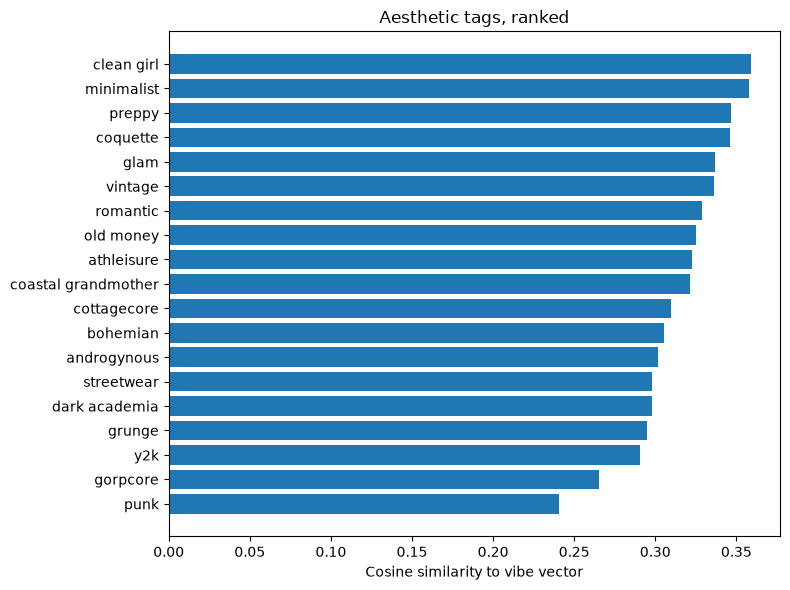

In [5]:
import matplotlib.pyplot as plt

all_sorted = torch.argsort(similarities, descending=True)
sorted_labels = [AESTHETIC_LABELS[i] for i in all_sorted]
sorted_scores = [similarities[i].item() for i in all_sorted]

plt.figure(figsize=(8, 6))
plt.barh(sorted_labels[::-1], sorted_scores[::-1])
plt.xlabel("Cosine similarity to vibe vector")
plt.title("Aesthetic tags, ranked")
plt.tight_layout()
plt.show()

In [6]:
from pathlib import Path
import numpy as np
import torch
from transformers import CLIPModel, CLIPProcessor

vibe_vector = np.load(Path("../data/embeddings/board_vibe_vector.npy"))

MODEL_NAME = "patrickjohncyh/fashion-clip"
device = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Using device: {device}")

model = CLIPModel.from_pretrained(MODEL_NAME).to(device)
model.eval()
processor = CLIPProcessor.from_pretrained(MODEL_NAME)

print("Model loaded. Vibe vector shape:", vibe_vector.shape)

Using device: mps


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Model loaded. Vibe vector shape: (512,)


In [7]:
AESTHETIC_LABELS = [
    "cottagecore", "dark academia", "y2k", "minimalist", "streetwear",
    "preppy", "grunge", "bohemian", "athleisure", "old money",
    "coquette", "gorpcore", "clean girl", "coastal grandmother",
    "punk", "romantic", "androgynous", "vintage", "glam",
]

PROMPT_TEMPLATE = "a photo of an outfit in the {} aesthetic"
prompts = [PROMPT_TEMPLATE.format(label) for label in AESTHETIC_LABELS]

prompts[:3]

['a photo of an outfit in the cottagecore aesthetic',
 'a photo of an outfit in the dark academia aesthetic',
 'a photo of an outfit in the y2k aesthetic']

In [8]:
inputs = processor(text=prompts, return_tensors="pt", padding=True).to(device)

with torch.no_grad():
    outputs = model.get_text_features(**inputs)

label_embeddings = outputs.pooler_output
label_embeddings = label_embeddings / label_embeddings.norm(dim=1, keepdim=True)

print("Label embeddings shape:", label_embeddings.shape)

Label embeddings shape: torch.Size([19, 512])


In [9]:
vibe_tensor = torch.from_numpy(vibe_vector).to(device)

similarities = label_embeddings @ vibe_tensor

TOP_K = 5
top_indices = torch.argsort(similarities, descending=True)[:TOP_K]

print("Top aesthetic tags for this board:\n")
for idx in top_indices:
    label = AESTHETIC_LABELS[idx]
    score = similarities[idx].item()
    print(f"  {label:<22} {score:.4f}")

Top aesthetic tags for this board:

  clean girl             0.3589
  minimalist             0.3579
  preppy                 0.3465
  coquette               0.3460
  glam                   0.3370


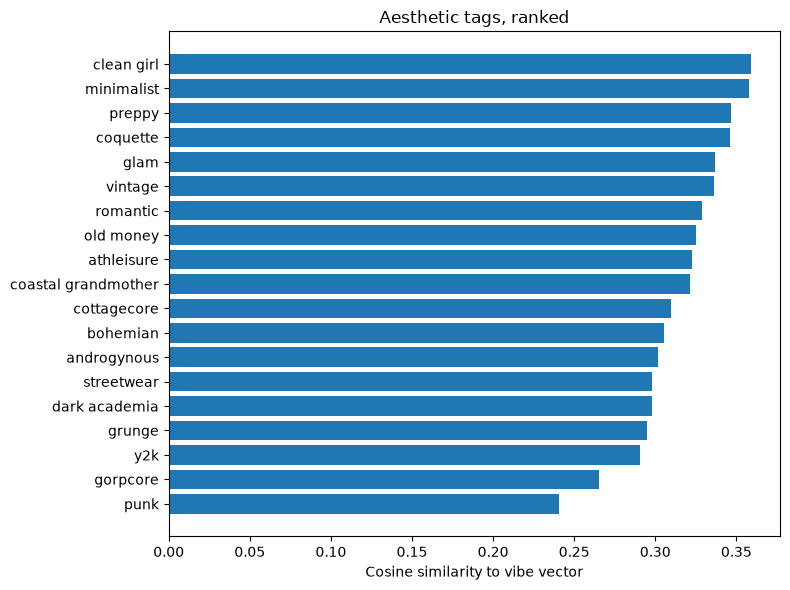

In [10]:
import matplotlib.pyplot as plt

all_sorted = torch.argsort(similarities, descending=True)
sorted_labels = [AESTHETIC_LABELS[i] for i in all_sorted]
sorted_scores = [similarities[i].item() for i in all_sorted]

plt.figure(figsize=(8, 6))
plt.barh(sorted_labels[::-1], sorted_scores[::-1])
plt.xlabel("Cosine similarity to vibe vector")
plt.title("Aesthetic tags, ranked")
plt.tight_layout()
plt.show()

## Save the ranked tags

Notebook 08 folds the single top-ranked aesthetic into every Depop query (e.g. `clean girl ribbed tee`), since Depop's own search is tuned for aesthetic vocabulary. Saving the full ranked list here means that step doesn't need to reload FashionCLIP just to re-derive it.

In [11]:
import json

aesthetic_tags_ranked = [
    {"tag": AESTHETIC_LABELS[i], "score": similarities[i].item()}
    for i in all_sorted
]

output_path = Path("../data/embeddings/aesthetic_tags.json")
with open(output_path, "w") as f:
    json.dump(
        {
            "top_tag": aesthetic_tags_ranked[0]["tag"],
            "top_5": [t["tag"] for t in aesthetic_tags_ranked[:5]],
            "all_tags_ranked": aesthetic_tags_ranked,
        },
        f,
        indent=2,
    )

print(f"Saved {len(aesthetic_tags_ranked)} ranked aesthetic tags to {output_path}")
print("Top tag (used in Depop queries):", aesthetic_tags_ranked[0]["tag"])

Saved 19 ranked aesthetic tags to ../data/embeddings/aesthetic_tags.json
Top tag (used in Depop queries): clean girl
